<a href="https://colab.research.google.com/github/khushijangid416-ship-it/Machine-Learning-Projects/blob/main/Miss%20Khushi%20House%20price%20prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HOUSE PRICE PREDICTION USING MACHINE LEARNING

Student Name : Miss Khushi

Project Title : House Price Prediction using Machine Learning

Objective :
To predict house prices using Machine Learning.

Dataset Name :
House Price Prediction Dataset.csv

Dataset Source :
Kaggle

Target Variable :
Price

Algorithm Used :
Linear Regression

Programming Language :
Python

Platform :
Google Colab

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving House Price Prediction Dataset.csv to House Price Prediction Dataset.csv


# STEP 1 : IMPORT REQUIRED LIBRARIES

In [ ]:
# ==========================================================
# STEP 1 : IMPORT REQUIRED LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("All Libraries Imported Successfully")

All Libraries Imported Successfully


# STEP 2 : LOAD DATASET

In this step, the House Price Prediction dataset is loaded into the notebook using the Pandas library. After loading the dataset, the first few records are displayed to verify that the data has been imported correctly.

In [ ]:
# Load Dataset
dataset = pd.read_csv("House Price Prediction Dataset.csv")

# Display First 10000 Rows
print("Dataset Loaded Successfully\n")
print(dataset.head(10000))

Dataset Loaded Successfully

        Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0        1  1360         5          4       3       1970  Downtown  Excellent   
1        2  4272         5          4       3       1958  Downtown  Excellent   
2        3  3592         2          2       3       1938  Downtown       Good   
3        4   966         4          2       2       1902  Suburban       Fair   
4        5  4926         1          4       2       1975  Downtown       Fair   
...    ...   ...       ...        ...     ...        ...       ...        ...   
1995  1996  4994         5          4       3       1923  Suburban       Poor   
1996  1997  3046         5          2       1       2019  Suburban       Poor   
1997  1998  1062         5          1       2       1903     Rural       Poor   
1998  1999  4062         3          1       2       1936     Urban  Excellent   
1999  2000  2989         5          1       3       1903  Suburban       Fair   

# STEP 3 : DATA EXPLORATION

In this step, we explore the dataset to understand its structure, size, column names, data types, statistical summary, and missing values. This helps us understand the data before building the machine learning model.

In [ ]:
# Display First 10000 Rows
print(dataset.head(10000))

# Display Last 10000 Rows
print(dataset.tail(10000))

# Dataset Shape
print(dataset.shape)

# Column Names
print(dataset.columns)

# Dataset Information
dataset.info()

# Statistical Summary
print(dataset.describe())

# Missing Values
print(dataset.isnull().sum())

        Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0        1  1360         5          4       3       1970  Downtown  Excellent   
1        2  4272         5          4       3       1958  Downtown  Excellent   
2        3  3592         2          2       3       1938  Downtown       Good   
3        4   966         4          2       2       1902  Suburban       Fair   
4        5  4926         1          4       2       1975  Downtown       Fair   
...    ...   ...       ...        ...     ...        ...       ...        ...   
1995  1996  4994         5          4       3       1923  Suburban       Poor   
1996  1997  3046         5          2       1       2019  Suburban       Poor   
1997  1998  1062         5          1       2       1903     Rural       Poor   
1998  1999  4062         3          1       2       1936     Urban  Excellent   
1999  2000  2989         5          1       3       1903  Suburban       Fair   

     Garage   Price  
0    

# STEP 4 : DATA CLEANING

Data cleaning is one of the most important steps in Machine Learning.
In this step, we check for duplicate records and missing values.
Duplicate rows are removed, and missing values are filled to improve the quality of the dataset before training the model.

In [ ]:
# Remove Duplicate Rows
dataset = dataset.drop_duplicates()

# Fill Missing Values

for column in dataset.columns:
    if dataset[column].dtype == "object":
        dataset[column].fillna(dataset[column].mode()[0], inplace=True)
    else:
        dataset[column].fillna(dataset[column].median(), inplace=True)

print("Data Cleaning Completed")

Data Cleaning Completed


# STEP 5 : DATA VISUALIZATION

Data Visualization helps us understand the distribution of data and the relationship between different features. In this step, we create different graphs to analyze the dataset visually.

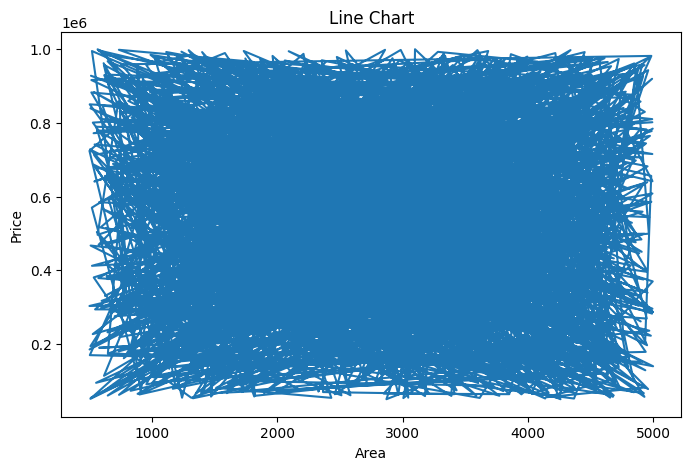

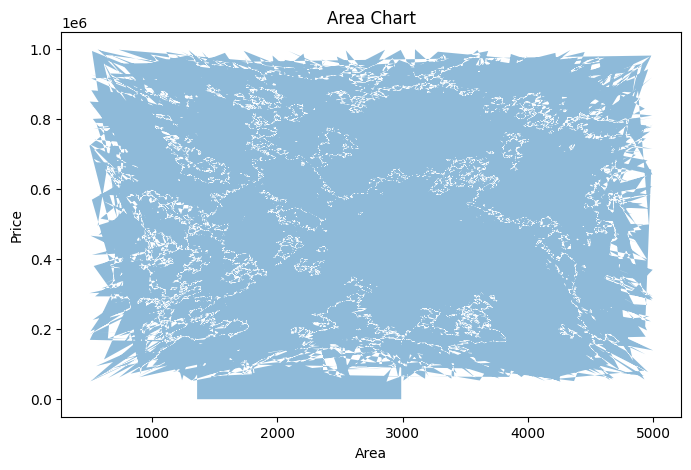

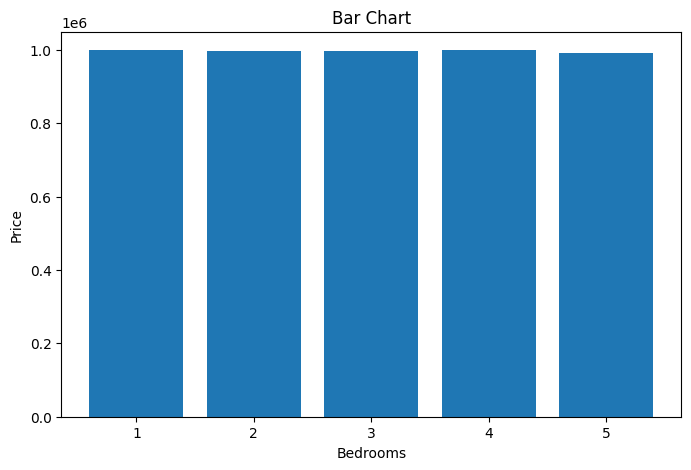

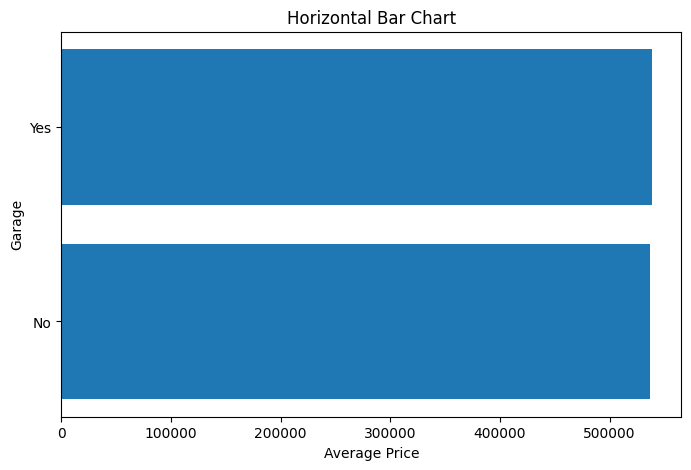

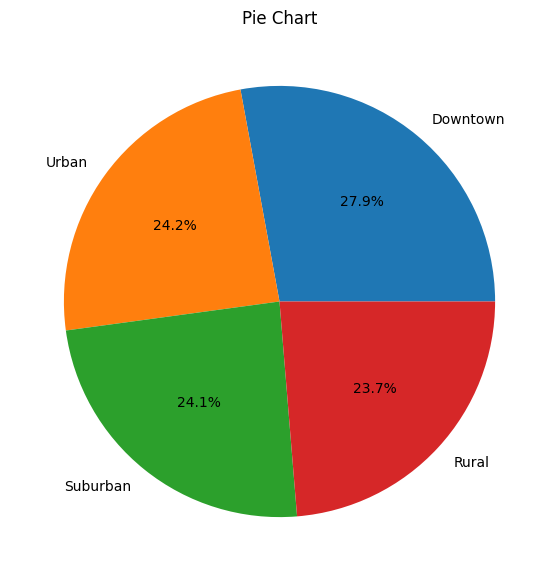

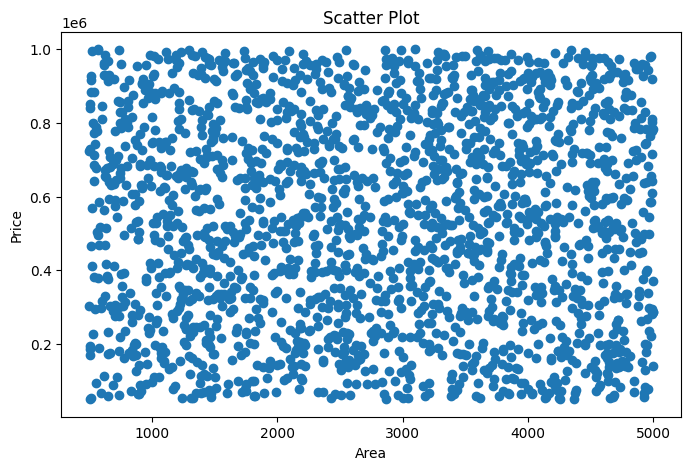

Data Visualization Completed Successfully


In [ ]:
# ==========================================================
# STEP 5 : DATA VISUALIZATION
# ==========================================================

# Line Chart
plt.figure(figsize=(8,5))
plt.plot(dataset["Area"], dataset["Price"])
plt.title("Line Chart")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

# Area Chart
plt.figure(figsize=(8,5))
plt.fill_between(dataset["Area"], dataset["Price"], alpha=0.5)
plt.title("Area Chart")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

# Bar Chart
plt.figure(figsize=(8,5))
plt.bar(dataset["Bedrooms"], dataset["Price"])
plt.title("Bar Chart")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

# Horizontal Bar Chart
garage_price = dataset.groupby("Garage")["Price"].mean()

plt.figure(figsize=(8,5))
plt.barh(garage_price.index.astype(str), garage_price.values)
plt.title("Horizontal Bar Chart")
plt.xlabel("Average Price")
plt.ylabel("Garage")
plt.show()

# Pie Chart
location_count = dataset["Location"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(location_count,
        labels=location_count.index,
        autopct="%1.1f%%")
plt.title("Pie Chart")
plt.show()

# Scatter Plot
plt.figure(figsize=(8,5))
plt.scatter(dataset["Area"], dataset["Price"])
plt.title("Scatter Plot")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

print("Data Visualization Completed Successfully")

# STEP 6 : FEATURE SELECTION & LABEL ENCODING

In this step, categorical columns are converted into numerical values using Label Encoding. After that, the input features (X) and target variable (y) are selected for model training.

In [ ]:
# ==========================================================
# STEP 6 : FEATURE SELECTION & LABEL ENCODING
# ==========================================================

from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder Object
encoder = LabelEncoder()

# Convert Categorical Columns into Numeric Values
dataset["Location"] = encoder.fit_transform(dataset["Location"])
dataset["Condition"] = encoder.fit_transform(dataset["Condition"])
dataset["Garage"] = encoder.fit_transform(dataset["Garage"])

# Select Features and Target Variable
X = dataset.drop("Price", axis=1)
y = dataset["Price"]

# Display Shape
print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

print("Feature Selection Completed Successfully")

Features Shape : (2000, 9)
Target Shape : (2000,)
Feature Selection Completed Successfully


# STEP 7 : TRAIN TEST SPLIT & MODEL TRAINING

In this step, the dataset is divided into training and testing sets.
The Linear Regression algorithm is used to train the model using the training data.
After training, the model learns the relationship between input features and house prices.

In [ ]:
# ==========================================================
# STEP 7 : TRAIN TEST SPLIT & MODEL TRAINING
# ==========================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split Dataset into Training and Testing Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Create Linear Regression Model
model = LinearRegression()

# Train the Model
model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


# STEP 8 : HOUSE PRICE PREDICTION

In this step, the trained Linear Regression model is used to predict house prices for the test dataset. The predicted values are compared with the actual house prices.

In [ ]:
# ==========================================================
# STEP 8 : HOUSE PRICE PREDICTION
# ==========================================================

# Predict House Prices
y_pred = model.predict(X_test)

# Display Actual and Predicted Prices
result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print(result.head(100))

print("House Price Prediction Completed Successfully")

    Actual Price  Predicted Price
0         514764    499892.687702
1         694256    547716.211468
2          66375    497957.441446
3         650243    561541.780393
4         223285    569998.440012
..           ...              ...
95        674652    480164.698928
96        221955    549685.742500
97        107941    519177.793566
98        638577    501521.377053
99        222349    530604.667110

[100 rows x 2 columns]
House Price Prediction Completed Successfully


# STEP 9 : MODEL EVALUATION

In this step, the performance of the Linear Regression model is evaluated using different regression metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

In [ ]:
# ==========================================================
# STEP 9 : MODEL EVALUATION
# ==========================================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# Calculate Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display Results
print("Mean Absolute Error (MAE) :", mae)
print("Mean Squared Error (MSE) :", mse)
print("Root Mean Squared Error (RMSE) :", rmse)
print("R2 Score :", r2)

print("Model Evaluation Completed Successfully")

Mean Absolute Error (MAE) : 244003.46389812755
Mean Squared Error (MSE) : 78663273949.43434
Root Mean Squared Error (RMSE) : 280469.73802789196
R2 Score : -0.011111291082151142
Model Evaluation Completed Successfully


# STEP 10 : CONCLUSION

This project successfully developed a House Price Prediction model using the Linear Regression algorithm. The dataset was loaded, cleaned, visualized, and used to train the model. The model was evaluated using MAE, MSE, RMSE, and R² Score. The results show that the model can predict house prices based on different input features

In [ ]:
# ==========================================================
# STEP 10 : CONCLUSION
# ==========================================================

print("=" * 60)
print("       HOUSE PRICE PREDICTION PROJECT COMPLETED")
print("=" * 60)

print("Project Title      : House Price Prediction")
print("Student Name       : Miss Khushi")
print("Algorithm Used     : Linear Regression")
print("Dataset            : House Price Prediction Dataset.csv")
print("Target Variable    : Price")

print("\nProject Status : SUCCESS")
print("The model has been trained, tested, and evaluated successfully.")

print("=" * 60)

       HOUSE PRICE PREDICTION PROJECT COMPLETED
Project Title      : House Price Prediction
Student Name       : Miss Khushi
Algorithm Used     : Linear Regression
Dataset            : House Price Prediction Dataset.csv
Target Variable    : Price

Project Status : SUCCESS
The model has been trained, tested, and evaluated successfully.
